# Visual Analytics

## Assignment 1

**Instructor:** Dr. Marco D'Ambros  
**TAs:** Giuseppe Crupi, Mattia Giannaccari

**Contacts:** marco.dambros@usi.ch, giuseppe.crupi@usi.ch, mattia.giannaccari@usi.ch

**Due Date:** 30 March, 2026 @ 23:55

---

### Goal

The goal of this assignment is to use Python and Jupyter notebook to explore, analyze and visualize the datasets provided. 

The assignment is divided into four sections, each requiring you to apply the knowledge gained from both the theoretical and practical lectures to solve the exercises. Specifically, when creating tabular or graphical representations, you should apply the principles learned in the theoretical lectures and use the technologies introduced in the practical sessions. The datasets you need to use are detailed in the **Datasets Description** section and can be found in the following folder [data-assignment1](https://drive.google.com/file/d/1e6FVt8i5WMFg8HLxmvhCExs_hv3lT5tx/view?usp=share_link).

---

### Allowed Python Libraries

Throughout the assignment, you may use the following Python libraries:
* `pandas` for data manipulation and analysis;
* `bokeh`, `matplotlib`, `seaborn`, and `hvplot` for data visualization;

**NB:** You are free to choose the library you prefer for each exercise or visualization task. The libraries listed above will be **evaluated equally**.

---

### AI policy

The usage of AI-based tools must be explicitly declared in your submission. If you use AI tools at any stage of the assignment, you must clearly state **how they were used** (e.g., generating code snippets, debugging, improving explanations, etc.).

This declaration should appear at the beginning of your notebook in a dedicated Markdown cell.

Please note that **you remain fully responsible for the submitted solution**. As instructors, we may ask you at any time to **orally explain parts of your solution**, including the reasoning behind the code, the data processing steps, and the visualizations you produced. If you are unable to clearly explain your own solution, this will be **evaluated negatively**.

---

### Submission Guidelines
- **Format:** Please submit a Jupyter Notebook containing your solutions along with a clear explanation of the **steps** taken to arrive at each solution. Each solution must be introduced by a Markdown cell indicating the exercise number. If you prefer, you may use the uploaded assignment file and develop your solution by adding cells below each exercise instructions. It is essential that every choice is justified, and the solution is thoroughly commented to explain each step. Exercises without explanations will be **evaluated negatively**.

- **Explanation and Justification:** All solutions must be **clearly explained and appropriately commented**. In particular, you should motivate and justify the choices you make, including data processing decisions, aggregation methods, and the selection of visualization techniques. Solutions that lack explanations or justification will be evaluated negatively.

- **Filename:** Please name the Jupyter notebook as follows: `SurnameName_Assignment1.ipynb`.

- **Submission:** Please submit your solution (the jupyter notebook and any other script you may have used to support your solution) to iCorsi.


---
## Section 1 - Data quality (10 points)

**Data Source:** `yellow_nyc.csv`.

Perform data cleaning and preprocessing steps on the dataset. Throughout the process, clearly document each step you take to clean and prepare the dataset. Your submission should describe both the methods used and the reasoning behind them.

### Data import
* Import the dataset.
* Convert all timestamp fields to an appropriate datetime format.
* Verify the data types of all remaining columns, and convert them to suitable formats where necessary (refer to the dataset documentation below).

### Data cleaning

Exploiting the column descriptions provided in the documentation below, identify potential inconsistencies in the dataset and perform appropriate data cleaning.

Examples:
* taxi rides take place in New York City; therefore, pickup or dropoff locations should not have geographical coordinates corresponding to extremely distant locations (e.g., Bogotá).
* the duration of a ride must be reasonable. Ride durations on the order of several days should be considered implausible and treated as inconsistent data instances.

Clearly document all decisions made during the process, as well as any assumptions that guided your cleaning steps.

### NB
* the size of the dataset can vary significantly after all the cleaning steps are performed.
* perform **all** the data cleaning operations you consider necessary, even if some of them do not result in a reduction of the dataset size.

### Step 1: Data Import

In this step, I load and inspect the raw dataset before applying any transformation. The objective is to understand the file structure, estimate its size, and verify that the import process is reliable.

In [ ]:
import pandas as pd
import numpy as np

In [30]:
! head "data-assignment1/yellow_nyc.csv"

pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
�2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.0009640731303908,-73.993896484375,40.7501106262207,-73.97478485107422,40.75061798095703,3,12.0,1.0,0.5,0.0,0.3,1.892
2015-01-10 20:33:38,2015-01-10 20:53:28,1,2.43860666648952,-74.00164794921875,40.7242431640625,-73.99441528320312,40.75910949707031,1,14.5,1.0,0.5,0.0,0.3,15.8
2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.6110557924967712,-73.96334075927734,40.80278778076172,-73.95182037353516,40.82441329956055,2,9.5,1.0,0.5,0.0,0.3,10.8
2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.49375957041270363,-74.00908660888672,40.71381759643555,-74.00432586669922,40.71998596191406,2,3.5,1.0,0.5,0.0,0.3,3.092783505154639
2015-01-10 20:33:39,2015-01-10 20:52:58,1,2.202531784441885,-73.97117614746094,40.762428283691406,-74.00418090820312,40.74

In [31]:
! wc -l data-assignment1/yellow_nyc.csv

 47248843 data-assignment1/yellow_nyc.csv


In [32]:
df = pd.read_csv("data-assignment1/yellow_nyc.csv", encoding="windows-1252")
df.info(memory_usage="deep")
df

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   pickup_time            str    
 1   dropoff_time           str    
 2   passenger_count        int64  
 3   trip_distance          float64
 4   pickup_longitude       float64
 5   pickup_latitude        float64
 6   dropoff_longitude      float64
 7   dropoff_latitude       float64
 8   payment_type           int64  
 9   fare_amount            float64
 10  overnight_tax          float64
 11  mta_tax                float64
 12  tolls_amount           float64
 13  improvement_surcharge  float64
 14  total_amount           float64
dtypes: float64(11), int64(2), str(2)
memory usage: 10.6 GB


,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
0,–2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.000964,-73.993896,40.750111,-73.974785,40.750618,3,12.0,1.0,0.5,0.00,0.3,1.892000
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,2.438607,-74.001648,40.724243,-73.994415,40.759109,1,14.5,1.0,0.5,0.00,0.3,15.800000
2,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.611056,-73.963341,40.802788,-73.951820,40.824413,2,9.5,1.0,0.5,0.00,0.3,10.800000
3,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.493760,-74.009087,40.713818,-74.004326,40.719986,2,3.5,1.0,0.5,0.00,0.3,3.092784
4,2015-01-10 20:33:39,2015-01-10 20:52:58,1,2.202532,-73.971176,40.762428,-74.004181,40.742653,2,15.0,1.0,0.5,0.00,0.3,16.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47248837,2016-01-31 23:30:32,2016-01-31 23:38:18,1,1.580833,-74.003578,40.751011,-73.982651,40.767509,2,8.5,1.0,0.5,0.00,0.3,9.800000
47248838,2016-01-05 00:15:55,2016-01-05 00:16:06,1,0.001597,-73.945488,40.751530,-73.945457,40.751530,2,2.5,1.0,0.5,0.00,0.3,3.800000
47248839,2016-01-05 06:12:46,2016-03-19 20:45:50,3,1.014583,-73.994240,40.766586,-73.984428,40.753922,2,7.5,1.0,0.5,0.00,0.3,8.800000
47248840,2016-01-05 06:21:44,2016-03-28 12:54:26,1,1.577206,-73.948067,40.776531,-73.978188,40.777435,1,11.5,0.0,0.5,0.00,0.3,12.300000


### Step 2: Column Type Verification

In this step, I standardize column data types to make the dataset consistent, memory-efficient, and ready for validation rules in the cleaning phase.

In [ ]:
# Convert ints -> int8
df["passenger_count"] = df["passenger_count"].astype("Int8")
df["payment_type"] = df["payment_type"].astype("Int8")

# Convert floats -> float32 (lat and log are kept as float64 as the documentation specifies)
float_cols = [
    "trip_distance",  "fare_amount",
    "overnight_tax", "mta_tax", "tolls_amount",
    "improvement_surcharge", "total_amount"
]
df[float_cols] = df[float_cols].astype("float32")

# check info after conversion
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   pickup_time            str    
 1   dropoff_time           str    
 2   passenger_count        Int8   
 3   trip_distance          float32
 4   pickup_longitude       float64
 5   pickup_latitude        float64
 6   dropoff_longitude      float64
 7   dropoff_latitude       float64
 8   payment_type           Int8   
 9   fare_amount            float32
 10  overnight_tax          float32
 11  mta_tax                float32
 12  tolls_amount           float32
 13  improvement_surcharge  float32
 14  total_amount           float32
dtypes: Int8(2), float32(7), float64(4), str(2)
memory usage: 8.8 GB


In [34]:
#  Remove any leading/trailing whitespace or dashes
df["pickup_time"] = df["pickup_time"].astype(str).str.strip().str.lstrip("–-")
df["dropoff_time"] = df["dropoff_time"].astype(str).str.strip().str.lstrip("–-")

# Convert strings -> datetime with second-level precision
df["pickup_time"] = pd.to_datetime(df["pickup_time"]).astype("datetime64[s]")
df["dropoff_time"] = pd.to_datetime(df["dropoff_time"]).astype("datetime64[s]")

# check info after conversion
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype        
---  ------                 -----        
 0   pickup_time            datetime64[s]
 1   dropoff_time           datetime64[s]
 2   passenger_count        Int8         
 3   trip_distance          float32      
 4   pickup_longitude       float64      
 5   pickup_latitude        float64      
 6   dropoff_longitude      float64      
 7   dropoff_latitude       float64      
 8   payment_type           Int8         
 9   fare_amount            float32      
 10  overnight_tax          float32      
 11  mta_tax                float32      
 12  tolls_amount           float32      
 13  improvement_surcharge  float32      
 14  total_amount           float32      
dtypes: Int8(2), datetime64[s](2), float32(7), float64(4)
memory usage: 3.5 GB


In [35]:
# payment_type: convert to pandas Categorical with explicit categories
payment_labels = {1: "Credit card", 2: "Cash", 3: "Voucher ride", 4: "Dispute", 5: "Unknown"}
df["payment_type"] = pd.Categorical(
    df["payment_type"].map(payment_labels),
    categories=["Credit card", "Cash", "Voucher ride", "Dispute", "Unknown"],
    ordered=False,
)


print(df.dtypes)
print("\nPayment type distribution:")
print(df["payment_type"].value_counts(dropna=False))
print("")

# check info after conversion
df.info(memory_usage="deep")


pickup_time              datetime64[s]
dropoff_time             datetime64[s]
passenger_count                   Int8
trip_distance                  float32
pickup_longitude               float64
pickup_latitude                float64
dropoff_longitude              float64
dropoff_latitude               float64
payment_type                  category
fare_amount                    float32
overnight_tax                  float32
mta_tax                        float32
tolls_amount                   float32
improvement_surcharge          float32
total_amount                   float32
dtype: object

Payment type distribution:
payment_type
Credit card     25870611
Cash            16158086
Voucher ride     5164138
Dispute            56004
Unknown                3
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype        
---  ------                 -----        
 0   pickup_time    

In [36]:
df.head()


,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
0,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.000964,-73.993896,40.750111,-73.974785,40.750618,Voucher ride,12.0,1.0,0.5,0.0,0.3,1.892000
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,2.438607,-74.001648,40.724243,-73.994415,40.759109,Credit card,14.5,1.0,0.5,0.0,0.3,15.800000
2,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.611056,-73.963341,40.802788,-73.951820,40.824413,Cash,9.5,1.0,0.5,0.0,0.3,10.800000
3,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.493760,-74.009087,40.713818,-74.004326,40.719986,Cash,3.5,1.0,0.5,0.0,0.3,3.092783
4,2015-01-10 20:33:39,2015-01-10 20:52:58,1,2.202532,-73.971176,40.762428,-74.004181,40.742653,Cash,15.0,1.0,0.5,0.0,0.3,16.299999


### Step 3: Data Cleaning

In this step, I remove inconsistent or implausible records using explicit domain rules from the assignment documentation and NYC taxi context.

Main decisions applied:
- remove exact duplicate rows, because they do not represent new information;
- keep only realistic passenger counts (greater than 0 and lower than 5);
- keep only trips with positive duration and a maximum of 24 hours; 
- keep rides whose pickup/dropoff coordinates fall inside a NYC bounding box;
- keep only plausible trip distances (greater than 0 and up to 50 miles);
- remove invalid fare/total values (negative values, and zero values for non-voucher rides);
- enforce tax consistency (`mta_tax`, `improvement_surcharge`, `overnight_tax`) using expected rule-based values;
- recompute `total_amount` and keep rows where the reported total matches the sum of components within a small tolerance.

In [39]:
# Shows count, mean, std, min, max, quartiles for numeric columns
df.describe()

,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
count,47248842,47248842,47248842.0,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,2015-11-01 19:34:24,2015-11-01 19:49:32,1.66704,2.243835e+01,-7.276452e+01,4.008471e+01,-7.282502e+01,4.011889e+01,1.239219e+01,4.876970e-01,4.977081e-01,2.843675e-01,2.952466e-01,1.210044e+01
min,2015-01-01 00:00:00,2015-01-01 00:00:00,0.0,0.000000e+00,-1.616987e+02,-7.703949e+01,-7.401667e+02,-7.703949e+01,-9.576000e+02,-7.900000e+01,-1.000000e+00,-9.999000e+01,-3.000000e-01,-4.497000e+02
25%,2015-01-30 07:34:07,2015-01-30 07:47:19,1.0,7.351069e-01,-7.399166e+01,4.073611e+01,-7.399120e+01,4.073459e+01,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,6.300000e+00
50%,2016-01-31 21:20:27,2016-01-31 21:35:51,1.0,1.262968e+00,-7.398155e+01,4.075335e+01,-7.397962e+01,4.075380e+01,9.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,9.300000e+00
75%,2016-03-02 05:54:00,2016-03-02 06:08:12,2.0,2.343939e+00,-7.396657e+01,4.076779e+01,-7.396225e+01,4.076920e+01,1.400000e+01,1.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,1.380000e+01
max,2016-03-31 23:59:59,2016-06-29 15:58:16,9.0,1.076793e+04,9.464387e+01,4.047000e+02,8.527402e+01,4.595333e+02,4.294967e+05,9.999900e+02,8.970000e+01,1.450090e+03,3.000000e-01,4.295622e+05
std,NaN,NaN,1.322092,3.306117e+02,9.381812e+00,5.168518e+00,9.150197e+00,5.040335e+00,7.861771e+01,6.152640e-01,4.672388e-02,1.657184e+00,3.812080e-02,7.317169e+01


In [40]:
# Check for null values in each column
df.isnull().sum()

pickup_time              0
dropoff_time             0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
overnight_tax            0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [41]:
# Exact duplicate rows are meaningless and should be removed.

n_before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {n_before - len(df):,}  |  Remaining: {len(df):,}")

Duplicates removed: 368  |  Remaining: 47,248,474


In [ ]:
# NYC taxis hold a maximum of 6 passengers and the taxi must not be empty.
# We remove counts below 0 or above 6 as clearly erroneous.

n_before = len(df)
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] < 7)]
print(f"Rows removed (bad passenger count): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (bad passenger count): 4,167,859  |  Remaining: 43,080,615


In [43]:
# Assumption: a ride cannot end before it starts, and a ride longer than 24 hours is implausible for a NYC taxi trip.

n_before = len(df)

duration_minutes = (df["dropoff_time"] - df["pickup_time"]).dt.total_seconds() / 60
df = df[(duration_minutes > 0) & (duration_minutes <= 24*60)]

print(f"Rows removed (bad duration): {n_before - len(df):,}  |  Remaining: {len(df):,}")
print(f"Duration range: {duration_minutes.min():.1f} – {duration_minutes.max():.1f} min")

Rows removed (bad duration): 51,196  |  Remaining: 43,029,419
Duration range: -537100.1 – 548555.6 min


In [44]:


# Rides with coordinates outside this NYC bounding box are likely data errors
# (NYC latitudes range roughly from 40.49 to 40.92, and longitudes from -74.27 to -73.68)

NYC_LAT  = (40.49, 40.92)
NYC_LON  = (-74.27, -73.68)

n_before = len(df)

geo_mask = (
    df["pickup_latitude"].between(*NYC_LAT)  &
    df["pickup_longitude"].between(*NYC_LON) &
    df["dropoff_latitude"].between(*NYC_LAT) &
    df["dropoff_longitude"].between(*NYC_LON)
)
df = df[geo_mask]

print(f"Rows removed (out-of-NYC coordinates): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (out-of-NYC coordinates): 789,361  |  Remaining: 42,240,058


In [45]:

# Distance must be non-negative.
# NYC is ~35 miles across; anything above 50 miles is implausible.

n_before = len(df)
df = df[df["trip_distance"] > 0]
df = df[df["trip_distance"] <= 50]
print(f"Rows removed (implausible distance): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (implausible distance): 186,616  |  Remaining: 42,053,442


In [46]:
# fare_amount and total_amount must be non-negative.

n_before = len(df)

# 1. Remove negative values
df = df[(df["total_amount"] >= 0) & (df["fare_amount"] >= 0)]

# 2. Remove zero values ONLY for non-voucher rides (because voucher rides can have zero fare)
non_voucher = df["payment_type"] != "Voucher ride"

df = df[~(
    non_voucher &
    ((df["fare_amount"] == 0) | (df["total_amount"] == 0))
)]

print(f"Rows removed (negative/zero fares): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (negative/zero fares): 17,758  |  Remaining: 42,035,684


In [47]:
#   mta_tax:                 $0.50 for trips < 5 miles, else $0
#   improvement_surcharge:   $0.30 for all rides (introduced 2016-01-01)
#   overnight_tax:           $1.00 for 00:00–06:00 pickups, else $0

n_before = len(df)

# ── MTA tax ─────────────────────────────────────────────
expected_mta = np.where(df["trip_distance"] < 5, 0.50, 0.00)
df = df[np.isclose(df["mta_tax"].astype(float), expected_mta, atol=0.01)]

# ── Improvement surcharge ───────────────────────────────
expected_imp = np.where(df["pickup_time"] >= pd.Timestamp("2016-01-01"), 0.30, 0.00)
df = df[np.isclose(df["improvement_surcharge"].astype(float), expected_imp, atol=0.01)]

# ── Overnight tax ──────────────────────────────────────
pickup_hour = df["pickup_time"].dt.hour
expected_overnight = np.where((pickup_hour >= 0) & (pickup_hour < 6), 1.00, 0.00)
df = df[np.isclose(df["overnight_tax"].astype(float), expected_overnight, atol=0.01)]

print(f"Rows removed (tax inconsistencies): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (tax inconsistencies): 24,212,553  |  Remaining: 17,823,131


In [48]:

# Per the documentation, total_amount = fare_amount + mta_tax + overnight_tax + improvement_surcharge + tolls_amount.

rn_before = len(df)

# Recompute expected total
recomputed_total = (
    df["fare_amount"].astype(float) +
    df["mta_tax"].astype(float) +
    df["overnight_tax"].astype(float) +
    df["improvement_surcharge"].astype(float) +
    df["tolls_amount"].astype(float)
)

# Keep only rows where total_amount matches expected value (with a small tolerance for floating-point imprecision)
df = df[np.isclose(df["total_amount"].astype(float), recomputed_total, atol=0.01)]

print(f"Rows removed (incorrect total_amount): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (incorrect total_amount): 30,087,740  |  Remaining: 11,947,944


In [51]:
# Final dataset summary 
print("=" * 55)
df.info(memory_usage="deep")
print("=" * 55)
df.describe()

<class 'pandas.DataFrame'>
Index: 11947944 entries, 67 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype        
---  ------                 -----        
 0   pickup_time            datetime64[s]
 1   dropoff_time           datetime64[s]
 2   passenger_count        Int8         
 3   trip_distance          float32      
 4   pickup_longitude       float64      
 5   pickup_latitude        float64      
 6   dropoff_longitude      float64      
 7   dropoff_latitude       float64      
 8   payment_type           category     
 9   fare_amount            float32      
 10  overnight_tax          float32      
 11  mta_tax                float32      
 12  tolls_amount           float32      
 13  improvement_surcharge  float32      
 14  total_amount           float32      
dtypes: Int8(1), category(1), datetime64[s](2), float32(7), float64(4)
memory usage: 991.3 MB


,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
count,11947944,11947944,11947944.0,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07,1.194794e+07
mean,2016-02-06 20:13:46,2016-02-06 20:27:05,1.287937,1.412356e+00,-7.397843e+01,4.075537e+01,-7.397903e+01,4.075476e+01,1.003273e+01,4.419170e-05,4.986070e-01,7.864407e-02,2.930911e-01,1.090312e+01
min,2015-01-01 00:18:22,2015-01-01 00:29:49,1.0,2.635705e-04,-7.426078e+01,4.049304e+01,-7.426887e+01,4.049294e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2016-01-22 09:49:40,2016-01-22 10:02:56,1.0,6.913111e-01,-7.399149e+01,4.074178e+01,-7.399165e+01,4.074131e+01,6.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,6.800000e+00
50%,2016-02-15 14:33:53,2016-02-15 14:45:17,1.0,1.099937e+00,-7.398093e+01,4.075647e+01,-7.398058e+01,4.075630e+01,8.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,9.300000e+00
75%,2016-03-08 14:25:00,2016-03-08 14:38:21,1.0,1.797995e+00,-7.396726e+01,4.077063e+01,-7.396838e+01,4.076900e+01,1.200000e+01,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,1.280000e+01
max,2016-03-31 23:59:07,2016-04-01 15:52:08,4.0,3.039182e+01,-7.368094e+01,4.091890e+01,-7.368041e+01,4.091985e+01,1.112709e+05,1.000000e+00,5.000000e-01,8.150000e+02,3.000000e-01,1.112716e+05
std,NaN,NaN,0.638813,1.100296e+00,2.168666e-02,2.312764e-02,2.400123e-02,2.413240e-02,3.290995e+01,6.647537e-03,2.635451e-02,9.681840e-01,4.499937e-02,3.301418e+01


---
## Section 2 - Data visualization (60 points)

**Data Source:** `stations.csv` and `air_pollution.csv`.



### Exercise 1 — City-Level Pollution Trends

**Preparation:**
Please perform the following steps:
* integrate the fields stored in the `stations.csv` file into the `air_pollution.csv` dataset.
* remove all rows containing missing values and explicitly identify the number of rows with null values.

**Questions:**
* which cities recorded the highest average PM2.5 levels in 2018, 2019 and 2020? Report the top 5 cities with their average values.

**Visualization:**

Retrieve the 5 cities with the highest pollution increase between 2018 and 2020 and create a visualization that:
* as a primary goal, shows the trend of PM2.5 absolute levels along the years, allowing easy comparison across cities.
* as a secondary goal, shows the absolute PM2.5 values for all years, emphasizing the values of 2020.

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:

# Load datasets 

air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")

air.info()
display(air.head())
print("\n")
station.info()
display(station.head())


<class 'pandas.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 11 columns):
 #   Column      Dtype  
---  ------      -----  
 0   stationid   str    
 1   datetime    str    
 2   pm2.5       float64
 3   pm10        float64
 4   no          float64
 5   no2         float64
 6   nox         float64
 7   co          float64
 8   so2         float64
 9   aqi         float64
 10  aqi_bucket  str    
dtypes: float64(8), str(3)
memory usage: 217.3 MB


,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,1.91525,16.35480,18.25,0.0873,4.52670,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.20050,12.85020,15.07,0.0873,5.03094,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,1.71150,13.37058,15.15,0.0873,4.61456,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.58925,8.62875,10.23,0.0873,3.99954,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.16545,9.28188,10.43,0.0873,3.48384,NaN,NaN




<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   StationId    230 non-null    str  
 1   StationName  230 non-null    str  
 2   City         230 non-null    str  
 3   State        230 non-null    str  
 4   Status       133 non-null    str  
dtypes: str(5)
memory usage: 9.1 KB


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [3]:
# Normalise the join key (case-insensitive column name matching)
# air_pollution uses 'stationid'; stations uses 'StationId' 
station_renamed = station.rename(columns={"StationId": "stationid"})

# Merge: left-join so we keep all pollution rows, when the station info is missing we get NaNs that we can audit and drop later
merged = air.merge(station_renamed, on="stationid", how="left")

# Count nulls BEFORE dropping
null_counts = merged.isnull().sum()
total_nulls = null_counts.sum()
rows_with_any_null = merged.isnull().any(axis=1).sum()

print("Null values per column:")
print(null_counts.to_string())
print(f"\nTotal null values      : {total_nulls}")
print(f"Rows containing a null : {rows_with_any_null}  (out of {len(merged)})")

# Drop rows that contain at least one NaN
df = merged.dropna().copy()
print(f"\nRows after dropping nulls: {len(df)}")

Null values per column:
stationid            0
datetime             0
pm2.5           647689
pm10           1119252
no              553711
no2             528973
nox             490808
co              499302
so2             742737
aqi             570190
aqi_bucket      570190
StationName          0
City                 0
State                0
Status            7706

Total null values      : 5730558
Rows containing a null : 1565882  (out of 2589083)

Rows after dropping nulls: 1023201


In [4]:
# Parse datetime and extract the year
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year

print(df["year"].value_counts().sort_index())
df.head()

year
2015     17890
2016     28117
2017     39171
2018    273990
2019    420366
2020    243667
Name: count, dtype: int64


,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status,year
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017


In [5]:
# Filter to years of interest
df_years = df[df["year"].isin([2018, 2019, 2020])].copy()

# Compute mean PM2.5 per city and year
city_year_pm25 = (
    df_years
    .groupby(["City", "year"])["pm2.5"]
    .mean()
    .reset_index()
    .rename(columns={"pm2.5": "avg_pm25"})
)

# Top-5 per year
for yr in [2018, 2019, 2020]:
    top5 = (
        city_year_pm25[city_year_pm25["year"] == yr]
        .nlargest(5, "avg_pm25")
        .reset_index(drop=True)
    )
    top5.index += 1          # rank starts at 1
    top5["avg_pm25"] = top5["avg_pm25"].round(2)
    print(f"\nTop-5 cities by average PM2.5 in {yr}")
    display(top5[["City", "avg_pm25"]])


Top-5 cities by average PM2.5 in 2018


,City,avg_pm25
1,Delhi,113.65
2,Kolkata,93.26
3,Talcher,91.44
4,Brajrajnagar,69.23
5,Jaipur,60.18



Top-5 cities by average PM2.5 in 2019


,City,avg_pm25
1,Patna,113.49
2,Delhi,107.63
3,Bhopal,67.29
4,Brajrajnagar,67.07
5,Chandigarh,63.83



Top-5 cities by average PM2.5 in 2020


,City,avg_pm25
1,Delhi,85.94
2,Talcher,79.71
3,Guwahati,74.17
4,Brajrajnagar,69.73
5,Gurugram,57.18


In [6]:
# Pivot: rows = cities, columns = years
pivot = city_year_pm25.pivot(index="City", columns="year", values="avg_pm25").dropna()

# Absolute increase: 2020 minus 2018
pivot["increase"] = pivot[2020] - pivot[2018]

top5_increase = pivot.nlargest(5, "increase").reset_index()
top5_increase_cities = top5_increase["City"].tolist()

print("5 cities with the highest absolute PM2.5 increase (2018→2020):")
print(top5_increase[["City", 2018, 2019, 2020, "increase"]].round(2).to_string(index=False))

5 cities with the highest absolute PM2.5 increase (2018→2020):
              City  2018  2019  2020  increase
            Mumbai 38.86 34.81 42.58      3.72
      Brajrajnagar 69.23 67.07 69.73      0.50
Thiruvananthapuram 32.95 28.96 26.95     -6.00
         Bengaluru 34.68 32.17 27.05     -7.64
         Hyderabad 43.42 41.42 35.18     -8.24


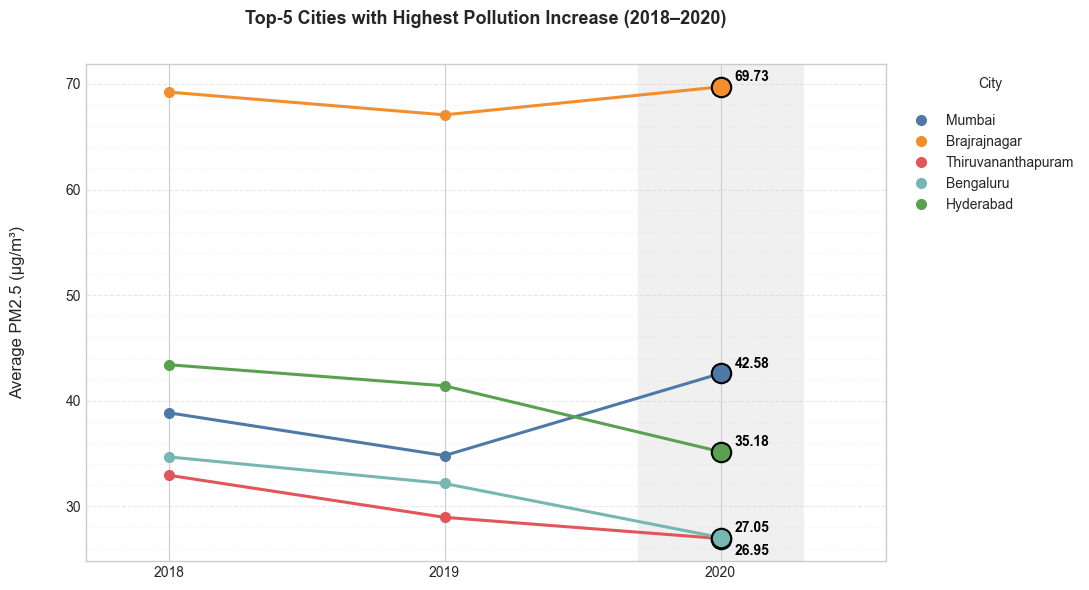

In [13]:
# Prepare plotting data
plot_data = city_year_pm25[city_year_pm25["City"].isin(top5_increase_cities)].copy()

# Colour palette — one distinct colour per city
palette = ["#4E79A7FF", "#F28E2BFF", "#E15759FF", "#76B7B2FF", "#59A14FFF"]
city_colors = {city: palette[i] for i, city in enumerate(top5_increase_cities)}

years = [2018, 2019, 2020]

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))


for city in top5_increase_cities:
    sub = plot_data[plot_data["City"] == city].sort_values("year")
    color = city_colors[city]

    # PRIMARY GOAL: line + markers for all years 
    ax.plot(sub["year"], sub["avg_pm25"],
            color=color, linewidth=2.2, zorder=2)

    ax.plot(sub["year"], sub["avg_pm25"],
            "o", color=color, markersize=7, zorder=3, label=city)

    # SECONDARY GOAL: emphasise 2020 with a larger, outlined marker
    val_2020 = sub.loc[sub["year"] == 2020, "avg_pm25"]
    if not val_2020.empty:
        ax.plot(2020, val_2020.values[0],
                "o", color=color, markersize=14,
                markeredgecolor="black", markeredgewidth=1.5, zorder=4)
        
        # Annotate 2020 value
        offset_y = 4
        if city  in ["Thiruvananthapuram"]:   # for these city, the 2020 value is better below the marker
                offset_y =  -12  
        
        ax.annotate(f"{val_2020.values[0]:.2f}",
                    xy=(2020, val_2020.values[0]),
                    xytext=(10, offset_y), textcoords="offset points",
                    fontsize=10, color="black", fontweight="bold")

# Axes & labels
ax.set_xticks(years)
ax.set_xlim(2017.7, 2020.6)
ax.set_ylabel("Average PM2.5 (µg/m³)\n\n", fontsize=12)
ax.set_title("Top-5 Cities with Highest Pollution Increase (2018–2020)\n",
             fontsize=13, fontweight="bold", pad=14)

ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.25)

ax.legend(title="City\n", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)

# Light shaded band behind 2020 column to draw visual attention
ax.axvspan(2019.7, 2020.3, color="#f0f0f0", zorder=0)


plt.tight_layout()
plt.show()

**Chart**

A line chart is the canonical choice for tracking a continuous quantitative variable (PM2.5) over an ordered time axis (years). It makes the *direction and magnitude of change* immediately readable and allows the five cities to be compared simultaneously through colour-coded lines.

To satisfy the **secondary goal** of emphasising 2020 I used three techniques:
1. The 2020 data point uses a larger, black-outlined marker — it pops visually compared to the plain circles used for 2018 and 2019.
2. The numeric value is annotated directly next to each 2020 point, removing the need for the reader to look up the y-axis.
3. A light grey vertical band is drawn behind the 2020 column to draw attention without distorting the data.


**Key insights from the visualization:**
- Mumbai shows the largest increase in PM2.5 (+3.72 µg/m³), indicating worsening air quality.
- Hyderabad and Bengaluru show the largest decreases, suggesting improvements in air quality.
- Most cities experienced fluctuations in 2019, but the trend by 2020 is clear.
- Brajrajnagar has consistently high pollution levels, although the absolute increase is small.

---
### Exercise 2 - Temporal Behavior of Pollutants

**Preparation:**

Please perform the following steps:
* compute the daily average concentration of pollutants across all cities.
* only consider the data points concerning the city of Delhi in the year 2019.
* only consider the following pollutants: $PM2.5$, $PM10$, $CO$, $NO$, $NO_2$.

**Visualization:**

Create a time series visualization that:
* shows the levels over time of the selected pollutants.
* allows comparison of relative fluctuations across comparable pollutants (details about the pollutants are reported in the documentation below).

**Questions:**
* do the levels of pollutants show any seasonality?
* do some pollutants appear to increase or decrease together?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

# Load and clean datasets again to run this cell independently
air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")
station_renamed = station.rename(columns={"StationId": "stationid"})
merged = air.merge(station_renamed, on="stationid", how="left")
df = merged.dropna().copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [24]:
# Pollutants of interest
POLLUTANTS = ["pm2.5", "pm10", "co", "no", "no2"]

# Filter: Delhi only, year 2019
delhi_2019 = df[
    (df["City"] == "Delhi") &
    (df["datetime"].dt.year == 2019)
].copy()

print(f"Delhi 2019 rows before daily aggregation: {len(delhi_2019)}")

# Add a date column (day-level granularity)
delhi_2019["date"] = delhi_2019["datetime"].dt.date

# daily average across ALL stations within Delhi
daily = (
    delhi_2019
    .groupby("date")[POLLUTANTS]
    .mean()
    .reset_index()
)

# cast date to datetime and sort by date
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

daily.head()

Delhi 2019 rows before daily aggregation: 204766
Daily rows (one per day): 365


,date,pm2.5,pm10,co,no,no2
0,2019-01-01,284.162004,454.401625,2.180719,73.592161,36.682170
1,2019-01-02,329.555712,512.574906,2.467909,79.514437,40.792434
2,2019-01-03,359.776158,517.629931,2.210427,64.261254,36.177176
3,2019-01-04,255.553541,395.353627,1.769778,40.839805,32.850466
4,2019-01-05,269.610052,417.397314,2.049054,56.255622,35.127196


In [29]:
# Z-score (standardise): subtract mean, divide by std
# This removes the unit/scale difference between µg/m³ and ppb, and lets us compare *relative fluctuations* on a single axis.
daily_norm = daily.copy()
for col in POLLUTANTS:
    mu  = daily[col].mean()
    std = daily[col].std()
    daily_norm[col] = (daily[col] - mu) / std

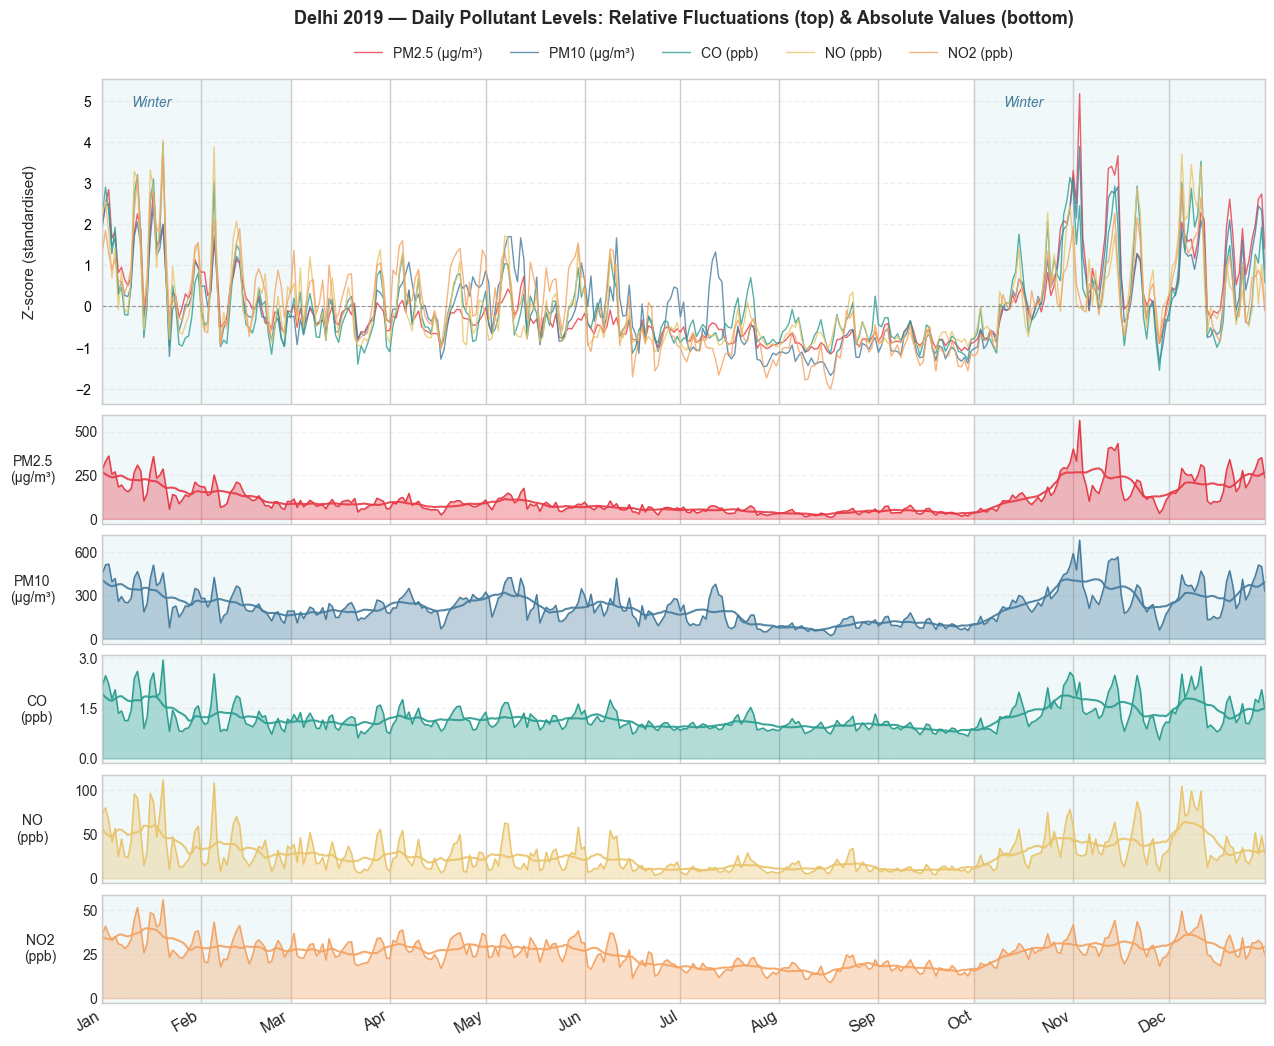

In [126]:
# Colour palette & display names 
colors = {
    "pm2.5": "#E63946",
    "pm10" : "#457B9D",
    "co"   : "#2A9D8F",
    "no"   : "#E9C46A",
    "no2"  : "#F4A261",
}
labels = {
    "pm2.5": "PM2.5 (µg/m³)",
    "pm10" : "PM10 (µg/m³)",
    "co"   : "CO (ppb)",
    "no"   : "NO (ppb)",
    "no2"  : "NO2 (ppb)",
}


# Top panel  → z-score normalised (relative fluctuation comparison)
# Bottom panel → absolute values, one sub-row per pollutant (raw scale)

fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(
    6, 1, figure=fig,
    height_ratios=[3, 1, 1, 1, 1, 1],
    hspace=0.08
)

dates = daily["date"]



# TOP PANEL: z-score overlay 
ax_top = fig.add_subplot(gs[0])

for pol in POLLUTANTS:
    ax_top.plot(dates, daily_norm[pol],
                color=colors[pol], linewidth=1,
                label=labels[pol], alpha=0.8)

ax_top.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.8)
ax_top.set_ylabel("Z-score (standardised)\n\n", fontsize=11)\

ax_top.set_title(
    "Delhi 2019 — Daily Pollutant Levels: Relative Fluctuations (top) & Absolute Values (bottom)\n\n",
    fontsize=13, fontweight="bold", pad=10
)

ax_top.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.14),
    ncol=5, fontsize=10, frameon=False
)

ax_top.set_xlim(dates.min(), dates.max())
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax_top.xaxis.set_major_locator(mdates.MonthLocator())
ax_top.tick_params(labelbottom=False)
ax_top.grid(axis="y", linestyle="--", alpha=0.3)

# Seasonal reference: shade winter months (Jan & Oct–Dec)
for start, end in [("2019-01-01", "2019-03-01"), ("2019-10-01", "2019-12-31")]:
    ax_top.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color="#d0e8f1", alpha=0.3, zorder=0)

ax_top.text(pd.Timestamp("2019-01-10"), ax_top.get_ylim()[1]*0.88, 
            "Winter", fontsize=10, color="#457B9D", style="italic")
ax_top.text(pd.Timestamp("2019-10-10"), ax_top.get_ylim()[1]*0.88,
            "Winter", fontsize=10, color="#457B9D", style="italic")

ax_top.tick_params(axis='y', labelsize=10, colors="black", pad=8)




# BOTTOM PANELS: one per pollutant (absolute values)
axes_bot = []

for i, pol in enumerate(POLLUTANTS):
    share = axes_bot[0] if i > 0 else None
    ax = fig.add_subplot(gs[i + 1], sharex=ax_top)
    axes_bot.append(ax)

    ax.fill_between(dates, daily[pol],
                    color=colors[pol], alpha=0.35)
    ax.plot(dates, daily[pol],
            color=colors[pol], linewidth=1)

    # Rolling 14-day mean to show trend
    roll = daily[pol].rolling(14, center=True, min_periods=5).mean()
    ax.plot(dates, roll,
            color=colors[pol], linewidth=1.5, linestyle="-",
            alpha=0.9)

    unit = "µg/m³" if pol in ("pm2.5", "pm10") else "ppb"
    ax.set_ylabel(f"{pol.upper()}\n({unit})", fontsize=10, rotation=0,
                  labelpad=30, va="center")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

    if i < len(POLLUTANTS) - 1:
        ax.tick_params(axis='y', labelsize=10)
        ax.tick_params(labelbottom=False)
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
        ax.tick_params(axis='y', labelsize=10) 


    # Shade same winter periods
    for start, end in [("2019-01-01", "2019-03-01"), ("2019-10-01", "2019-12-31")]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color="#d0e8f1", alpha=0.3, zorder=0)
    
        

plt.show()



The chart is split into **two complementary panels**:

1. **Top panel — Z-score overlay (primary goal: relative fluctuation comparison)**  
   Because the five pollutants are measured in different units (µg/m³ vs ppb) and span
   very different numeric ranges (PM10 can reach thousands while NO₂ stays in the tens),
   plotting raw values on a single axis would make the lower-magnitude pollutants invisible.
   Z-score standardisation (subtract mean, divide by standard deviation) rescales every
   pollutant to a mean of 0 and a standard deviation of 1, so the *shape* and *timing* of
   fluctuations can be compared directly. Overlapping lines on this shared axis immediately
   reveal which pollutants rise and fall together.

2. **Bottom panels — Small-multiple absolute value plots (secondary goal: raw scale)**  
   One fill-area strip per pollutant preserves the actual concentration values for reference.
   A 14-day rolling mean (solid line) is overlaid to show the underlying seasonal trend
   while suppressing day-to-day noise. The small-multiple layout avoids overplotting while
   keeping all panels horizontally aligned so temporal events can be traced across pollutants.

Light-blue shading marks the **winter months** (Jan–Mar and Oct–Dec), which are the
expected high-pollution season in Delhi due to reduced wind, temperature inversions, and
increased biomass burning.

---

**Seasonality**

- Concentrations are markedly higher in January–February and again from October to december,
  forming a U-shaped pattern over the year.
- PM2.5 and PM10 show the sharpest winter peaks, which aligns with Delhi's well-documented
  severe winter smog episodes driven by crop stubble burning, firecrackers (Diwali, October),
  and cold-weather temperature inversions that trap pollutants near the surface.

**Co-movement of pollutants**

- **PM2.5 and PM10** move almost in lockstep (strongly positively correlated).
  sources that generate coarse particles also generate fine ones.
- **NO and NO₂** also track each other closely throughout the year. Both are nitrogen
  oxides produced primarily by vehicular combustion; NO is rapidly oxidised to NO₂ in the
  atmosphere, so they share both source and chemical pathway.
- **CO** broadly follows the same seasonal rhythm as the nitrogen oxides (high in winter,
  low in summer), consistent with a shared combustion origin (traffic, generators, biomass
  burning), though its day-to-day fluctuations are somewhat smoother.


---
### Exercise 3 - Pollution Composition Across AQI Categories
The dataset includes the Air Quality Index (AQI) and the corresponding AQI bucket, which classifies air quality conditions. The classes of severity are the following (sorted from the least to the most severe): `Good`, `Satisfactory`, `Moderate`, `Poor`, `Very Poor`, `Severe`.

**Visualization:**

Create one or more visualizations aimed at answering the following questions.

**Questions:**
* which pollutants appear to dominate in absolute terms across the different AQI categories?
* do the relative contributions change across AQI categories?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

# Load and clean datasets again to run this cell independently
air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")
station_renamed = station.rename(columns={"StationId": "stationid"})
merged = air.merge(station_renamed, on="stationid", how="left")
df = merged.dropna().copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [132]:
# ── Define the ordered severity scale ─────────────────────────────────────────
AQI_ORDER = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

# ── Pollutants to analyse ─────────────────────────────────────────────────────
# We exclude NOx (redundant with NO+NO2) and AQI/aqi_bucket (non-pollutant columns).
# NH3 is kept because it is a distinct chemical species.
POLLUTANTS = ["pm2.5", "pm10", "no", "no2", "co", "so2"]

POL_LABELS = {
    "pm2.5" : "PM2.5",
    "pm10"  : "PM10",
    "no"    : "NO",
    "no2"   : "NO₂",
    "co"    : "CO",
    "so2"   : "SO₂",
}

# ── Compute mean concentration per pollutant per AQI bucket ───────────────────
aqi_means = (
    df
    .groupby("aqi_bucket")[POLLUTANTS]
    .mean()
    .reindex(AQI_ORDER)          # enforce severity order
)

print("\nMean concentration per AQI category:")
print(aqi_means.round(2))


Mean concentration per AQI category:
               pm2.5    pm10     no    no2    co   so2
aqi_bucket                                            
Good           14.46   34.05   4.42   6.45  0.34  2.79
Satisfactory   29.73   66.92   7.29  11.64  0.60  3.45
Moderate       56.20  135.78  14.84  19.41  0.91  4.71
Poor           90.34  212.76  24.09  25.08  1.13  5.86
Very Poor     152.99  273.88  38.16  31.83  1.57  6.49
Severe        256.32  448.53  57.39  39.09  3.13  7.52


In [133]:
# ── Row-wise normalisation → each row sums to 100% ───────────────────────────
# This answers: "what share of the total measured concentration does each
# pollutant account for within a given AQI category?"
aqi_pct = aqi_means.div(aqi_means.sum(axis=1), axis=0) * 100

print("\nRelative contributions (%) per AQI category:")
print(aqi_pct.round(2))


Relative contributions (%) per AQI category:
              pm2.5   pm10    no    no2    co   so2
aqi_bucket                                         
Good          23.13  54.48  7.07  10.32  0.54  4.46
Satisfactory  24.85  55.94  6.09   9.73  0.50  2.89
Moderate      24.24  58.56  6.40   8.37  0.39  2.03
Poor          25.15  59.22  6.70   6.98  0.32  1.63
Very Poor     30.30  54.24  7.56   6.30  0.31  1.29
Severe        31.57  55.24  7.07   4.81  0.39  0.93


In [134]:
# ── One distinct colour per pollutant ─────────────────────────────────────────
POL_COLORS = {
    "pm2.5" : "#E63946",   # red
    "pm10"  : "#457B9D",   # steel blue
    "no"    : "#E9C46A",   # yellow
    "no2"   : "#F4A261",   # orange
    "nh3"   : "#8ECAE6",   # light blue
    "co"    : "#2A9D8F",   # teal
    "so2"   : "#9B5DE5",   # purple
}

# ── AQI category colours (background severity cues) ───────────────────────────
AQI_COLORS = {
    "Good"        : "#55A868",
    "Satisfactory": "#8FBC55",
    "Moderate"    : "#F0C040",
    "Poor"        : "#F28E2B",
    "Very Poor"   : "#E05C5C",
    "Severe"      : "#8B0000",
}

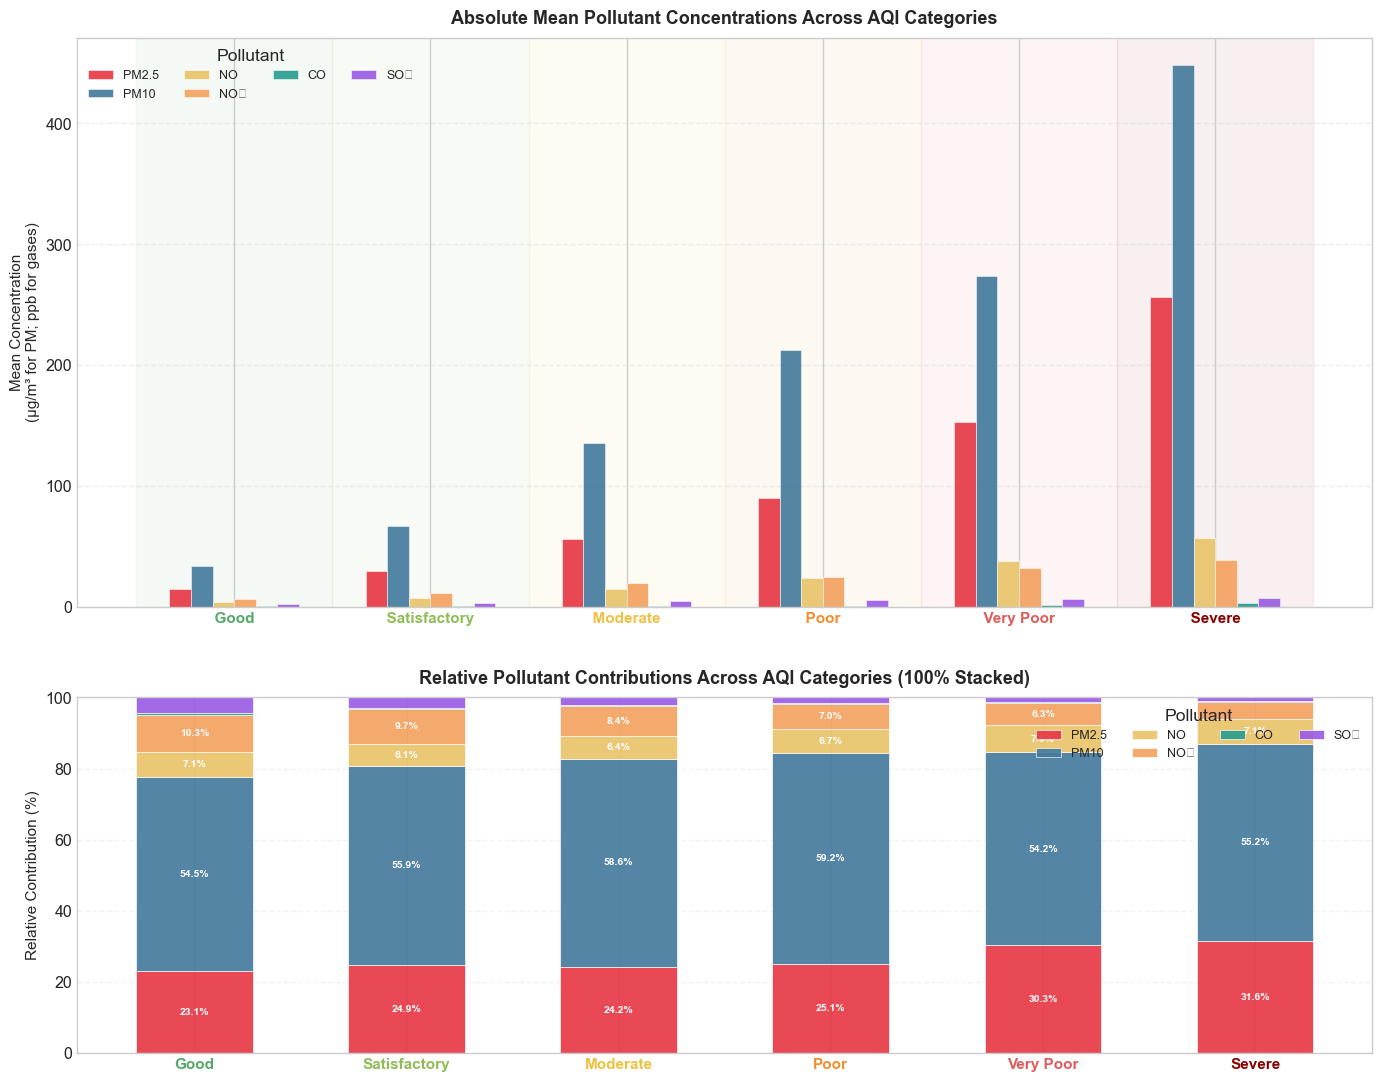

In [135]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 11),
    gridspec_kw={"height_ratios": [1.6, 1]}
)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 1 — Grouped bar chart: ABSOLUTE concentrations
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0]

n_cats = len(AQI_ORDER)
n_pols = len(POLLUTANTS)
bar_width = 0.11
x = np.arange(n_cats)

for i, pol in enumerate(POLLUTANTS):
    offset = (i - n_pols / 2 + 0.5) * bar_width
    vals   = aqi_means[pol].values
    bars   = ax1.bar(x + offset, vals,
                     width=bar_width,
                     color=POL_COLORS[pol],
                     label=POL_LABELS[pol],
                     edgecolor="white", linewidth=0.4,
                     alpha=0.92)

# AQI category severity colour on x-axis tick labels
ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"  {cat}  " for cat in AQI_ORDER],
    fontsize=11
)
for tick, cat in zip(ax1.get_xticklabels(), AQI_ORDER):
    tick.set_color(AQI_COLORS[cat])
    tick.set_fontweight("bold")

ax1.set_ylabel("Mean Concentration\n(µg/m³ for PM; ppb for gases)", fontsize=11)
ax1.set_title(
    "Absolute Mean Pollutant Concentrations Across AQI Categories",
    fontsize=13, fontweight="bold", pad=10
)
ax1.legend(
    title="Pollutant", loc="upper left",
    fontsize=9, ncol=4, framealpha=0.9, edgecolor="lightgrey"
)
ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.set_axisbelow(True)

# Light AQI-severity gradient on background
for i, cat in enumerate(AQI_ORDER):
    ax1.axvspan(i - 0.5, i + 0.5,
                color=AQI_COLORS[cat], alpha=0.06, zorder=0)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 2 — 100% stacked bar chart: RELATIVE contributions
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]

bottoms = np.zeros(n_cats)
for pol in POLLUTANTS:
    vals = aqi_pct[pol].values
    ax2.bar(
        x, vals,
        bottom=bottoms,
        color=POL_COLORS[pol],
        label=POL_LABELS[pol],
        edgecolor="white", linewidth=0.5,
        width=0.55,
        alpha=0.92
    )
    # Annotate segments wider than 6%
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 6:
            ax2.text(
                j, b + v / 2,
                f"{v:.1f}%",
                ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold"
            )
    bottoms += vals

ax2.set_xticks(x)
ax2.set_xticklabels(AQI_ORDER, fontsize=11)
for tick, cat in zip(ax2.get_xticklabels(), AQI_ORDER):
    tick.set_color(AQI_COLORS[cat])
    tick.set_fontweight("bold")

ax2.set_ylim(0, 100)
ax2.set_ylabel("Relative Contribution (%)", fontsize=11)
ax2.set_title(
    "Relative Pollutant Contributions Across AQI Categories (100% Stacked)",
    fontsize=13, fontweight="bold", pad=10
)
ax2.legend(
    title="Pollutant", loc="upper right",
    fontsize=9, ncol=4, framealpha=0.9, edgecolor="lightgrey"
)
ax2.grid(axis="y", linestyle="--", alpha=0.25)
ax2.set_axisbelow(True)

plt.tight_layout(h_pad=2.5)
plt.savefig("ex3_aqi_composition.png", dpi=150, bbox_inches="tight")
plt.show()

---
### Exercise 4 - Correlation Between Pollutants

Air pollutants often originate from common sources such as traffic emissions, industrial activities, and combustion processes. As a result, some pollutants may exhibit strong correlations.

**Visualization:**

Create a visualization that clearly shows which pollutants exhibit the strongest correlation.

**Questions:**
* which pollutants exhibit the strongest positive correlations?
* are there pollutants showing weak or negative correlations with others?
* can you identify groups of pollutants that might originate from similar sources?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [ ]:
# Write your solution here

---
### Exercise 5 - Seasonal Pollution Patterns

Air pollution often exhibits seasonal patterns due to factors such as weather conditions, heating demand, and industrial activity.

**Preparation:**

* only consider the following pollutants: $PM2.5$, $PM10$, $CO$, $NO$, $NO_2$, $SO_2$.

**Visualization:**

Create one or more visualizations that clearly shows how pollutant levels vary, month by month, throughout the year. The visualization should allow an easy comparison of the seasonal patterns across pollutants.
* as a primary goal, hightlight the absolute variability of the pollutants across the months of the year.
* as a secondary goal, for each month of the year, show the variability of the concentration of each pollutant with respect to its median value.

**Questions:**
* which pollutants exhibit the strongest seasonal variation?
* are there pollutants that peak in different seasons than others?
* do particulate pollutants (PM2.5 and PM10) behave differently from gaseous pollutants?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

---
## Section 3 - Graph Redesign and Analysis (20 points)

**Data Source:** `market_value_decline.csv`

The 2008 financial crisis had a significant impact on banks worldwide, leading to substantial losses in market value. The following graph compares the market value of major banks in 2007 (pre-crisis) and 2009 (post-crisis), using blue to represent their value before the meltdown and green to represent their value after.

The **primary** goal of this visualization is to highlight the extent of losses suffered by each bank, while also drawing attention to J.P. Morgan’s relatively minor decline compared to its peers. The **secondary** goal is to illustrate the overall ranking of banks by market value, showing their relative sizes before and after the crisis.

Does this visualization effectively convey both the absolute losses and the percentage changes in market value? Does it allow for an easy comparison of which banks retained the most value relative to their original size?

1. Evaluate the effectiveness of the graph in communicating the market value losses and the relative sizes of the banks. What improvements can be made?
2. Propose a visualization that better captures both the absolute and relative losses per bank. Should we emphasize the percentage decline more? Should we use a different chart type?
3. Implement your proposed visualization using the *market_value_decline* dataset.

**Exercise Submission Requirements:**
1. `Written analysis` of the original graph's shortcomings: Please examine the existing graph and identify any issues that hinder its ability to clearly convey the intended quantitative message.
2. `Justifications` for the proposed improvements: For each issue you identify, please discuss potential improvements or alternative visualization techniques that might resolve these issues.
3. `Redesigned graph` that better communicates the data. Be sure to explain how your redesign enhances data interpretation and achieves the intended objectives more effectively.

![./exercise3.png](exercise3.png)




In [ ]:
# Write your solution here

## Section 4 - Geospatial Medal Visualization (30 points)

**Data Source:** `medals_total.csv`, `athletes.csv`.

Please create an interactive world map showing the Olympic performance of each country in Paris 2024. The visualization should include a dropdown menu with three possible metrics: **gold medals**, **total medals**, and **efficiency**. Selecting a different metric from the dropdown should update the map coloring so that countries are shaded according to the chosen value.

The efficiency metric should be defined as: **efficiency = total medals / number of athletes**

In addition, clicking on a country should display, **in a secondary output widget**, the distribution of athlete ages for that country.

Your final result should be runnable in a Jupyter notebook.

In [ ]:
# Write your solution here

## Datasets description

You can find the data in the folder [data-assignment1](https://drive.google.com/file/d/1e6FVt8i5WMFg8HLxmvhCExs_hv3lT5tx/view?usp=share_link). The descriptions of the datasets are provided below.

### Yellow NYC

Data file `yellow_nyc.csv`:

| Column                    | Description |
|------------------------------|---------------|
| `pickup_time`               | Date and time when the ride began (`datetime`). |
| `dropoff_time`              | Date and time when the ride ended (`datetime`). |
| `passenger_count`              | Number of passengers in the vehicle. |
| `pickup_longitude`              | Longitude of the pickup location (type `float64`). |
| `pickup_latitude`              | Latitude of the pickup location (type `float64`). |
| `dropoff_longitude`              | Longitude of the dropoff location (type `float64`). |
| `dropoff_latitude`              | Latitude of the dropoff location (type `float64`). |
| `trip_distance`              | Distance covered during the ride in miles. |
| `payment_type`              | Method used to pay for the ride (e.g., credit card, cash). If the ride is a `Voucher ride`, the passenger is not charged for the ride, as the fare is already covered by a pre-purchased voucher. |
| `fare_amount`              | Base fare charged for the ride, excluding surcharges and tolls. |
| `mta_tax`              | \$0.50 MTA tax. Automatically triggered for rides shorter than 5 miles, \$0 otherwise. |
| `overnight_tax`              | Additional surcharge: \$1.00 for rides starting between midnight and 6am, \$0 otherwise. |
| `improvement_surcharge`              | Additional \$0.30 surcharge applied to every ride. Introduced on January 1st, 2016. |
| `tolls_amount`              | Total toll charges incurred during the ride. |
| `total_amount`              | Total amount charged to the passenger, including fare, all surcharges, and tolls. |

#### Payment Type Encoding
| **Code**                    | **Payment Method** |
|------------------------------|---------------|
| 1               | Credit card |
| 2               | Cash |
| 3               | Voucher ride |
| 4               | Dispute |
| 5               | Unknown |

### Air pollution

Data file `air_pollution.csv`:

| Column                    | Description |
|------------------------------|---------------|
| `stationid`                 | Unique identifier of the station. |
| `datetime`                  | Date and time when the measure was recorded (`datetime`). |
| `pm2.5`                     | Measured concentration of Particulate Matter 2.5-micrometer. Unit of measure: $\mu g / m^3$|
| `pm10`                      | Measured concentration of Particulate Matter 10-micrometer. Unit of measure: $\mu g / m^3$ |
| `no`                        | Measured concentration of Nitric Oxide. Unit of measure: $ppb$ |
| `no2`                       | Measured concentration of Nitric Dioxide. Unit of measure: $ppb$ |
| `nox`                       | Measured concentration of any Nitric x-oxide. Unit of measure: $ppb$ |
| `nh3`                       | Measured concentration of Ammonia. Unit of measure: $ppb$ |
| `co`                        | Measured concentration of Carbon Monoxide. Unit of measure: $ppb$ |
| `so2`                       | Measured concentration of Sulphur Dioxide. Unit of measure: $ppb$ |
| `aqi`                       | Air Quality Index. A standardized index used to report air quality levels. |
| `aqi_bucket`                       | A categorical subdivision between different ranges of AQI. |

### Stations dataset

Data file `stations.csv`:
| Column                    | Description |
|------------------------------|---------------|
| `StationId`                 | Unique identifier of the station. |
| `StationName`               | Name of the station. |
| `City`                      | City where the station is. |
| `State`                     | State where the station is. |
| `Status`                    | Station activity status. |


### Paris 2024 olympic summer games

Data file `medals_total.csv`:

| Column | Description |
|---|---|
| `country_code` | IOC 3-letter country code (e.g. `USA`, `GBR`, `GER`) |
| `country` | Country name |
| `country_long` | Full country name |
| `Gold Medal` | Number of gold medals won |
| `Silver Medal` | Number of silver medals won |
| `Bronze Medal` | Number of bronze medals won |
| `Total` | Sum of all medals (gold + silver + bronze) |

Data file `athletes.csv`:

| Column | Description |
|---|---|
| `code` | Unique numeric identifier for the person |
| `current` | Boolean — whether the record is current/active |
| `name` | Full official name |
| `name_short` | Shortened display name (usually "Firstname LASTNAME") |
| `name_tv` | Name formatted for TV broadcast graphics |
| `gender` | `Male` or `Female` |
| `function` | Role at the Games — `Athlete`, `Coach`, `Technical Official`, etc. |
| `country_code` | IOC 3-letter code of the competing country (e.g. `USA`, `GER`) |
| `country` | Short country name |
| `country_long` | Full official country name |
| `nationality` | Short nationality label |
| `nationality_long` | Full nationality label |
| `nationality_code` | IOC code for nationality (may differ from `country_code` for naturalised athletes) |
| `height` | Height in metres |
| `weight` | Weight in kilograms |
| `disciplines` | Sport discipline(s) the athlete is entered in |
| `events` | Specific event(s) within those disciplines |
| `birth_date` | Date of birth (YYYY-MM-DD) |
| `birth_place` | City/town of birth |
| `birth_country` | Country of birth |
| `residence_place` | City/town of current residence |
| `residence_country` | Country of current residence |
| `nickname` | Athlete's popular nickname or alias |
| `hobbies` | Self-reported hobbies and interests |
| `occupation` | Job or occupation outside of sport |
| `education` | Educational background |
| `family` | Free-text description of family situation |
| `lang` | Languages spoken |
| `coach` | Name(s) of the athlete's coach(es) |
| `reason` | Why the athlete started their sport |
| `hero` | Person(s) the athlete identifies as a hero or role model |
| `influence` | Greatest influence on their career |
| `philosophy` | Personal or sporting philosophy/motto |
| `sporting_relatives` | Family members who also compete in sport |
| `ritual` | Pre-competition rituals or superstitions |
| `other_sports` | Other sports the athlete practises |